## TIFON Databases. Read and load example databases

In [1]:
# Cargar pylom manualmente si no está el paquete pyLOM en el environment cargado (to Copilot):
try:
    import pyLOM
    print('Environment with pylom instaled')
except ImportError:
    import sys
    sys.path.append('/home/m.jaraiz/repos/pyLowOrder/')
from FotR import FRODO, SAM

def read_db(datafolder, case_idx, make_data_dict:bool = True):
    db = FRODO(root_dir = datafolder, format = 'CODA', initial_parse = True)
    
    if make_data_dict:
        db.extract_inputs(
            id_groups = (3,),
            cases_idx = case_idx,
            vtu_type='surface',
            verbose=False
            )

        for stage in [0, 1]:
            
            db.extract_outputs(
                id_groups=(3,),
                stage=stage, cases_idx = case_idx,
                var_name_excluded = [
                    'BoundaryValues_CoefSkinFrictionX',
                    'BoundaryValues_CoefSkinFrictionY',
                    'BoundaryValues_CoefSkinFrictionZ'
                    ],
                vtu_type='surface',
                )
    
    return db

0 Warning! Import - NVTX not present!


In [2]:
db_1 = read_db('/home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_propose_0/', case_idx='all', make_data_dict=False)


 NEW CODA SIMULATION WILL BE LOADED FROM /home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_propose_0
100 simulations found.
Parse took: 0.0687 s


### Residuals

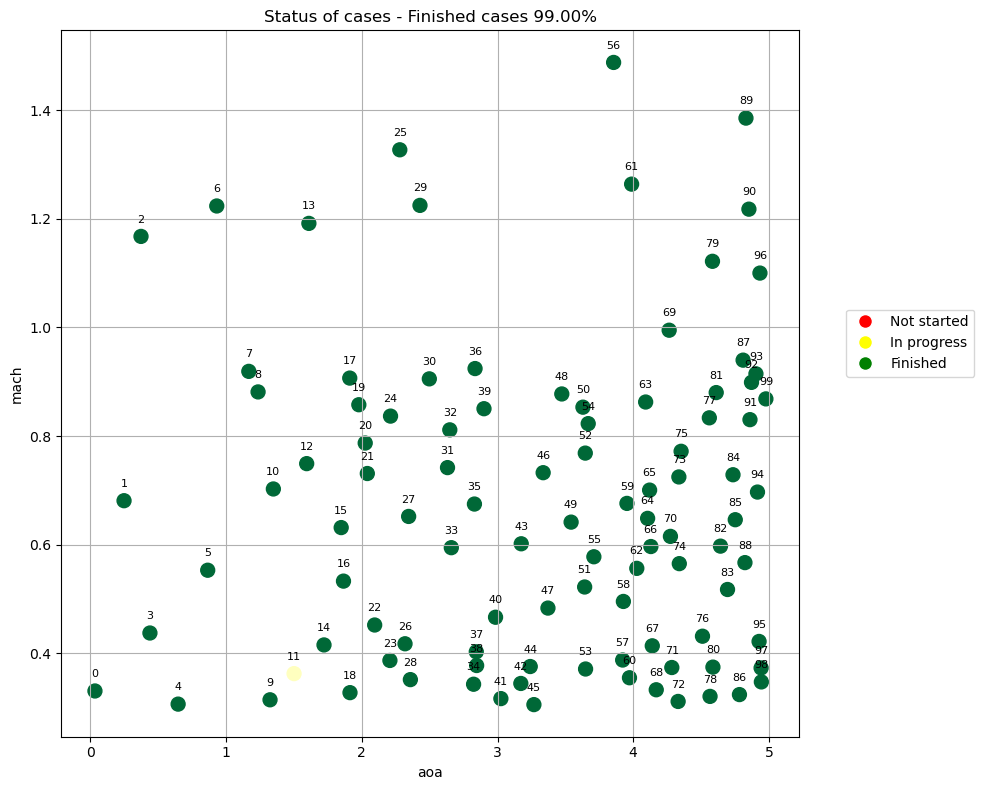

In [3]:
db_1.plot_state()

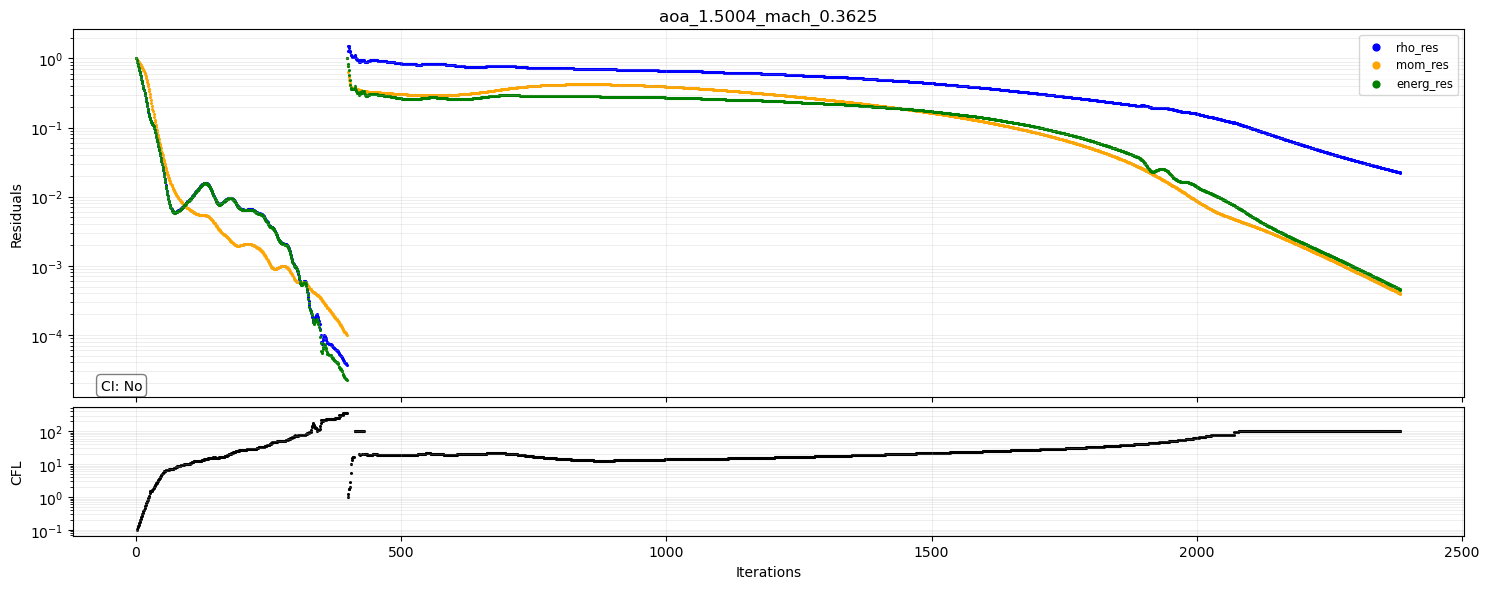

In [11]:
db_1.residuals.plot_state_calculation(num_stages=1, txt_from_end=1)

### Calculate df_post from get_df_metrics()

In [ ]:
for c in range(95,100):
    db_1.residuals.plot_residuals_from_case(
        case_idx = c,
        stage = [0, 1],
        mode = 'scaled'
    )

In [ ]:
db_1.residuals.plot_all_final_residuals(mode='scaled', stage=[0,], lim_converged=1e-4, only_finished=True, print_non_converged=False, activate_idx=True)

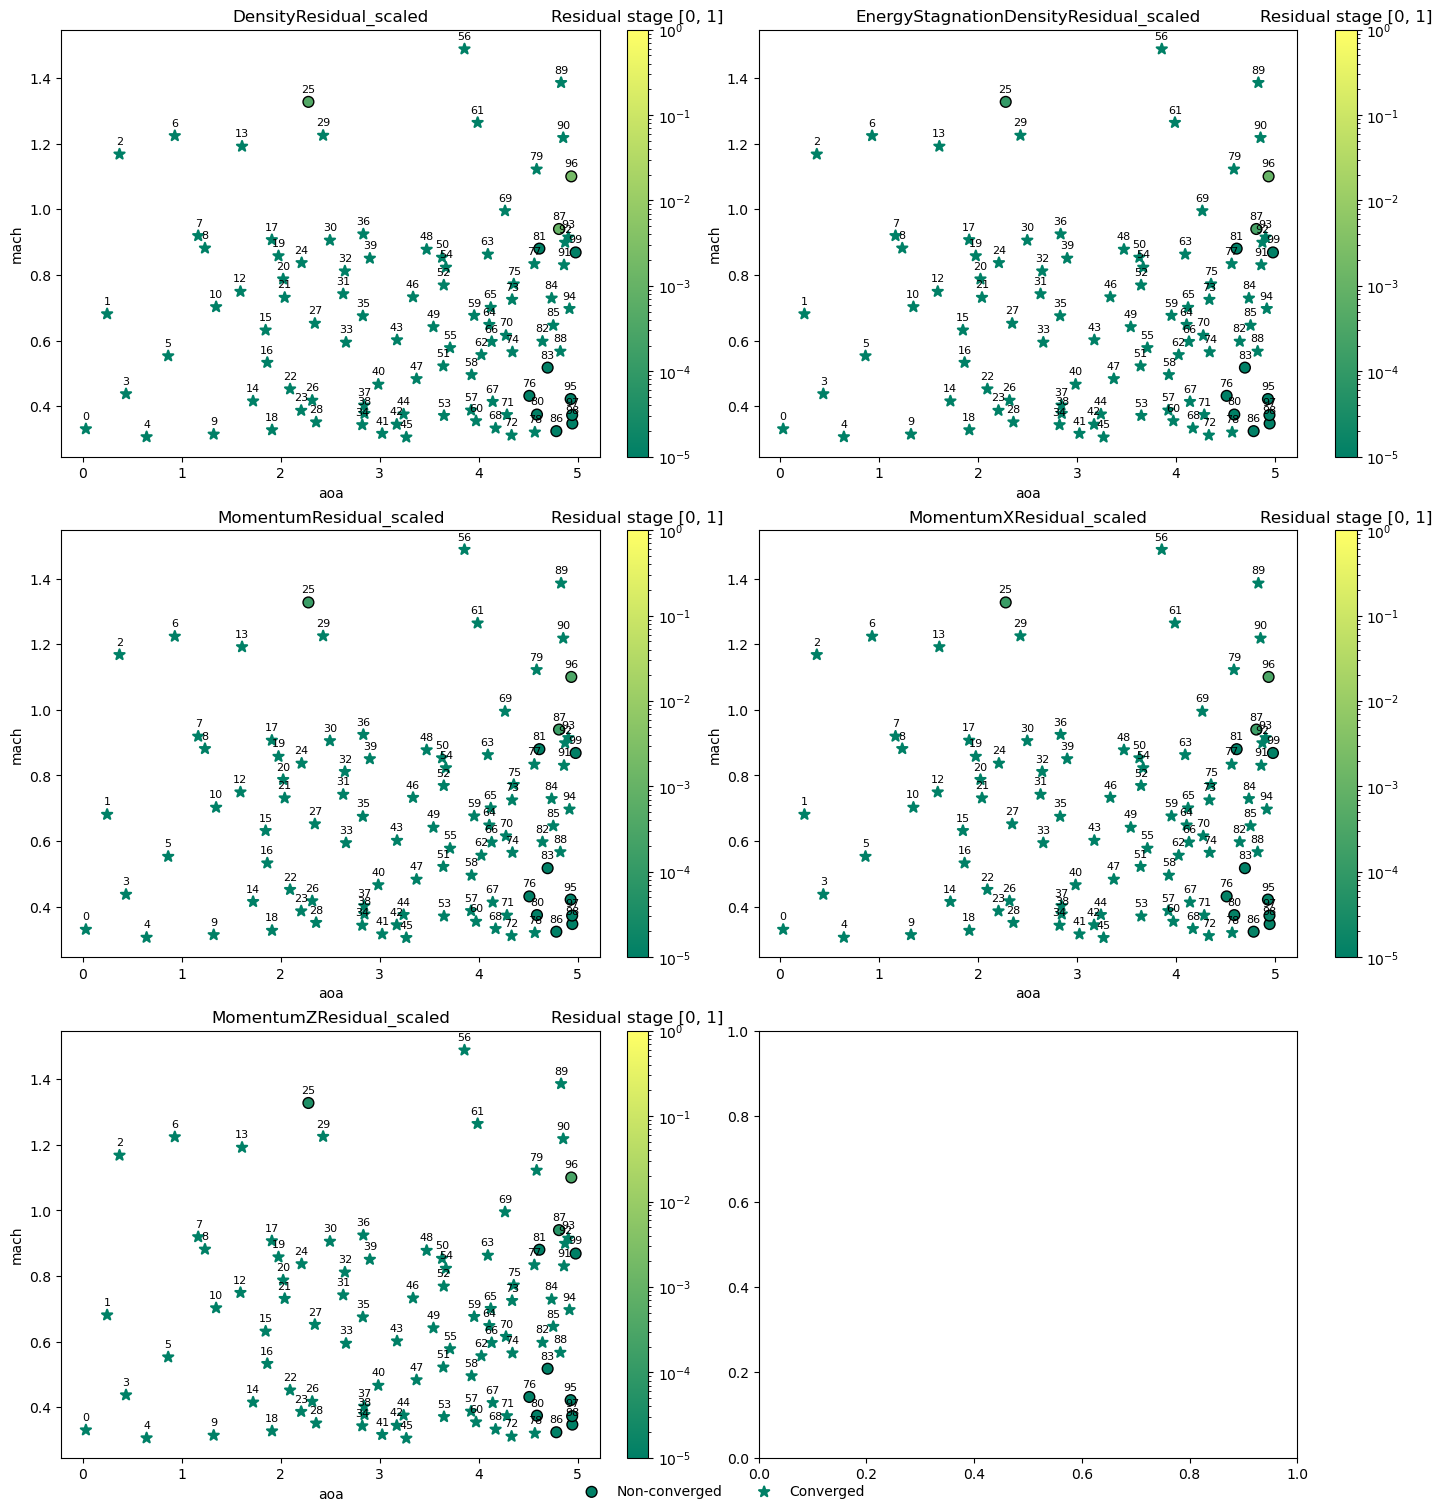

In [5]:
db_1.residuals.plot_all_final_residuals(mode='scaled', stage=[0, 1], lim_converged=1e-5, only_finished=True, print_non_converged=False, activate_idx=True)

In [ ]:
all = list(range(80))
to_remove = [0, 3, 4, 6, 7, 9, 13, 15, 16, 19, 25, 28, 31, 39, 42, 45, 50, 54, 60, 63, 69, 72, 75]
print(1-(len(to_remove)/len(all)))

Skipping 'aoa_1.5004_mach_0.3625': not finished.


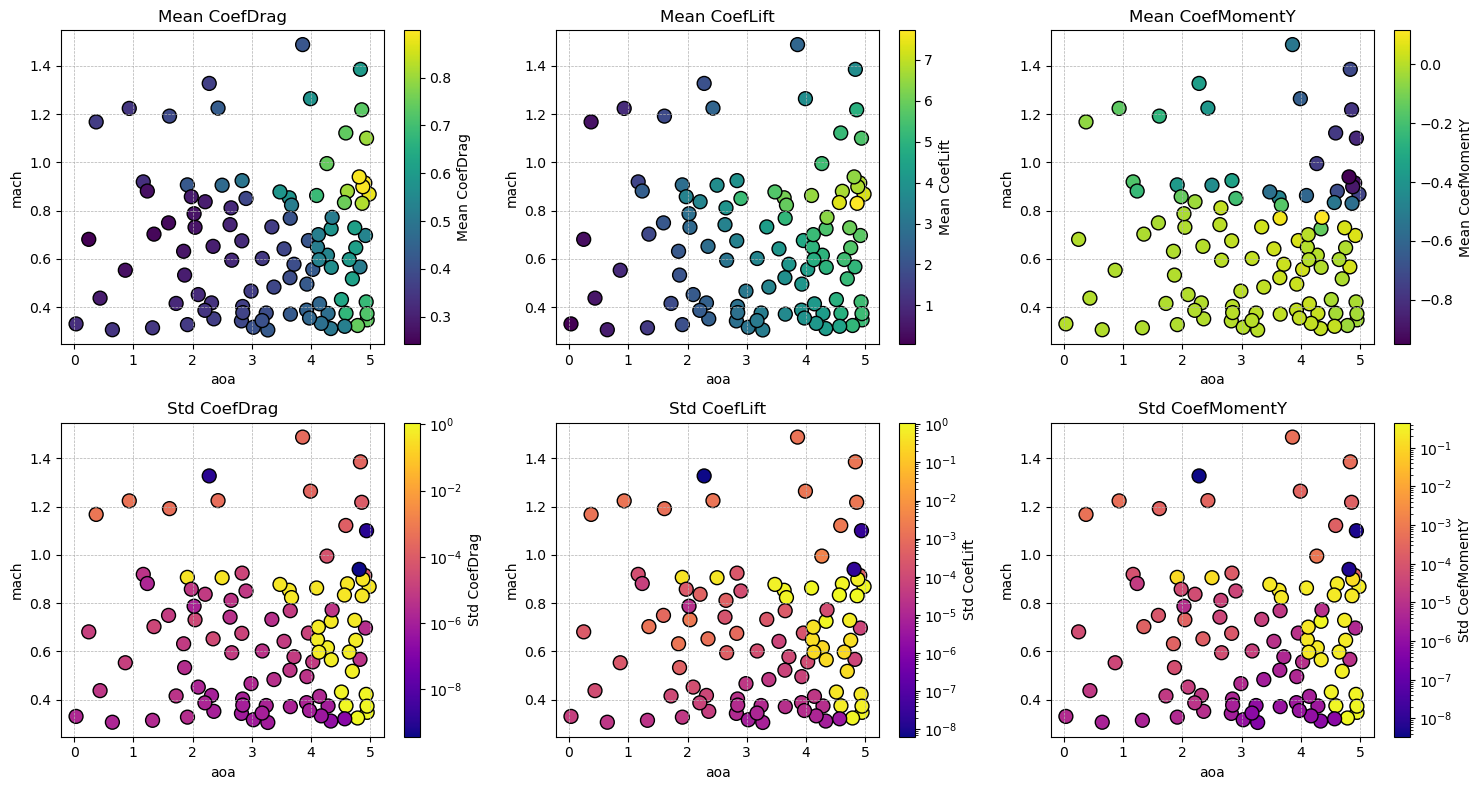

In [8]:
res_mean, res_std = db_1.residuals.integrals_convergence_criteria(
    iterations_back = 1000,
    only_finished = True,
    only_converged = False, 
    mode = '2D',
    plot=True,
    residual_threshold = 1e-3,
    verbose=True
)

In [ ]:
df_finals = db_1.residuals.get_all_final_residuals(verbose=False, stage=[0,], only_finished=False, load_in_metadata=False)
display(df_finals)

In [ ]:
db_1.metadata

In [ ]:
df_post = db_1.residuals.get_df_metrics(var_metrics = ['CoefLift', 'CoefDrag', 'CoefMomentY'],
        iter_var = 1000,
        save =  True
)

In [ ]:
import plotly.express as px

# Método para pintar figura de px donde se vea col1 vs col2 de df_post, indicando también col3 para color y booleano para pintar línea x=y

def plot_df_post(df_post, col1:str, col2:str, col3:str = None, line_xy:bool = True):
    if col3 is not None:
        fig = px.scatter(df_post, x=col1, y=col2, color=col3, hover_data=df_post.columns)
    else:
        fig = px.scatter(df_post, x=col1, y=col2, hover_data=df_post.columns)
    
    if line_xy:
        min_val = min(df_post[col1].min(), df_post[col2].min())
        max_val = max(df_post[col1].max(), df_post[col2].max())
        fig.add_shape(type='line', x0=min_val, y0=min_val, x1=max_val, y1=max_val,
                      line=dict(color='Red', dash='dash'))
    
    fig.update_layout(
        # title=f'Scatter plot of {col1} vs {col2}',
        xaxis_title=col1,
        yaxis_title=col2
        )
    fig.show()

In [ ]:
plot_df_post(df_post, col1='CoefDrag_mean_stage0', col2='CoefDrag_mean_stage1', col3='mach', line_xy=True)
plot_df_post(df_post, col1='CoefLift_mean_stage0', col2='CoefLift_mean_stage1', col3='aoa', line_xy=True)

plot_df_post(df_post, col1='CoefLift_mean_stage0', col2='CoefLift_mean_stage1', col3='mach', line_xy=True)
plot_df_post(df_post, col1='aoa', col2='CoefLift_mean_stage1', col3='mach', line_xy=False)
plot_df_post(df_post, col1='CoefLift_mean_stage1', col2='CoefDrag_mean_stage1', col3='mach', line_xy=False)

In [ ]:

fig = px.scatter(
    df_post,
    x='CoefDrag_mean_stage0',
    y='CoefDrag_mean_stage1',
    color='mach',
    hover_data=['case_idx', 'mach']
)

fig.show()
fig = px.scatter(
    df_post,
    x='CoefLift_mean_stage0',
    y='CoefLift_mean_stage1',
    color='mach',
    hover_data=['case_idx', 'mach']
)
fig.show()
fig = px.scatter(
    df_post,
    x="aoa",
    y="CoefLift_mean_stage1",
    color="mach",
    # title="CL vs AoA"
)
fig.show()
fig = px.scatter(
    df_post,
    x="CoefDrag_mean_stage1",
    y="CoefLift_mean_stage1",
    color="aoa"
)
fig.show()
fig = px.scatter(
    df_post,
    x="CoefDrag_mean_stage1",
    y="CoefLift_mean_stage1",
    color="mach"
)
fig.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# -------------------------
# Renderer para VSCode
# -------------------------
pio.renderers.default = "vscode"

# -------------------------
# Crear subplots
# -------------------------
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        "Stage0 vs Stage1 (CL)",
        "Polar CL vs AoA",
        "Drag Polar (CL vs CD)"
    )
)

# -------------------------
# 1. CL Stage0 vs Stage1
# -------------------------
fig.add_trace(
    go.Scatter(
        x=df_post['CoefLift_mean_stage0'],
        y=df_post['CoefLift_mean_stage1'],
        mode='markers',
        marker=dict(
            color=df_post['aoa'],
            colorscale='Viridis',
            colorbar=dict(title="AoA"),
            showscale=True
        ),
        text=df_post['case_idx'],
        customdata=df_post[['mach']],
        hovertemplate=
        "CL0=%{x}<br>CL1=%{y}<br>AoA=%{marker.color}<br>Mach=%{customdata[0]}<br>Case=%{text}",
        name="CL stage comparison"
    ),
    row=1, col=1
)

# -------------------------
# 2. Polar CL vs AoA
# -------------------------
fig.add_trace(
    go.Scatter(
        x=df_post["aoa"],
        y=df_post["CoefLift_mean_stage1"],
        mode="markers",
        marker=dict(
            color=df_post["mach"],
            colorscale="Viridis",
            showscale=False
        ),
        text=df_post["case_idx"],
        hovertemplate=
        "AoA=%{x}<br>CL=%{y}<br>Mach=%{marker.color}<br>Case=%{text}",
        name="Polar"
    ),
    row=1, col=2
)

# -------------------------
# 3. Drag polar
# -------------------------
fig.add_trace(
    go.Scatter(
        x=df_post["CoefDrag_mean_stage1"],
        y=df_post["CoefLift_mean_stage1"],
        mode="markers",
        marker=dict(
            color=df_post["aoa"],
            colorscale="Viridis",
            showscale=False
        ),
        text=df_post["case_idx"],
        customdata=df_post[['mach']],
        hovertemplate=
        "CD=%{x}<br>CL=%{y}<br>AoA=%{marker.color}<br>Mach=%{customdata[0]}<br>Case=%{text}",
        name="Drag polar"
    ),
    row=1, col=3
)

# -------------------------
# Layout
# -------------------------
fig.update_layout(
    height=500,
    width=1400,
    title="CFD Interactive Analysis Dashboard",
)

# -------------------------
# Interactividad extra (selector dataset)
# -------------------------
datasets = df_post['dataset'].unique()

buttons = []
for s in datasets:
    mask = df_post['stage'] == s

    visible = []
    for _ in range(3):  # 3 traces
        visible.append(True)

    buttons.append(dict(
        label=s,
        method="update",
        args=[{
            "x": [
                df_post.loc[mask, 'CoefLift_mean_stage0'],
                df_post.loc[mask, 'aoa'],
                df_post.loc[mask, 'CoefDrag_mean_stage1']
            ],
            "y": [
                df_post.loc[mask, 'CoefLift_mean_stage1'],
                df_post.loc[mask, 'CoefLift_mean_stage1'],
                df_post.loc[mask, 'CoefLift_mean_stage1']
            ],
        }]
    ))

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=0.0,
            y=1.2,
            showactive=True
        )
    ]
)

fig.show()